In [1]:
from rocketpy import Rocket, Environment, SolidMotor, GenericMotor, MonteCarlo, Flight

In [25]:
# datos geográficos reales del punto de lanzamiento de la base del TELENO

env.set_atmospheric_model(
    type="standard_atmosphere",
    pressure=101325, 
    temperature=293, 
    wind_u=0, # mejorar función logarítmica
    wind_v=0,
)


Gravity Details

Acceleration of gravity at surface level:    9.8038 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5616 m/s²


Launch Site Details

Launch Date: 2025-10-14 12:00:00 UTC
Launch Site Latitude: 42.34022°
Launch Site Longitude: -6.27134°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 230509.49 W    4692736.81 N
Launch Site UTM zone: 30T
Launch Site Surface Elevation: 1.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 1013.13 hPa
Surface Temperature: 288.14 K
Surface Air Density: 1.225 kg/m³
Surface Speed of Sound: 340.29 m/s


Earth Model Details

Earth Radius at Launch site: 6368.48 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



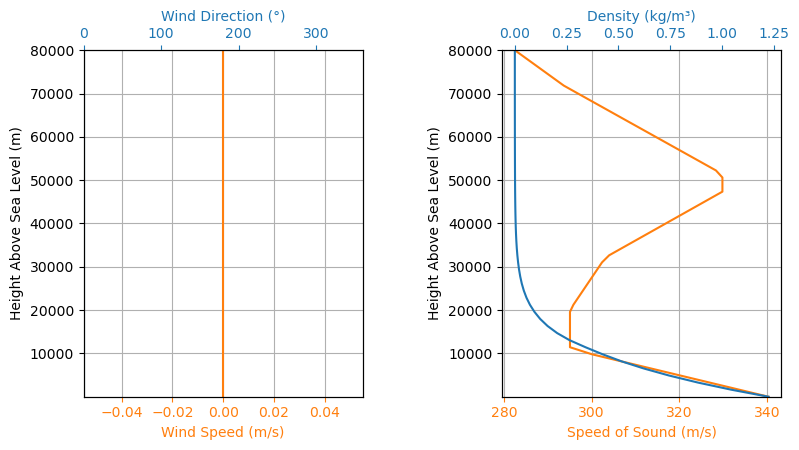

In [26]:
env.info()

Motor Details
Total Burning Time: 8.993 s
Total Propellant Mass: 0.350 kg
Structural Mass Ratio: 0.566
Average Propellant Exhaust Velocity: 1781.664 m/s
Average Thrust: 69.666 N
Maximum Thrust: 332.429 N at 0.043 s after ignition.
Total Impulse: 623.582 Ns



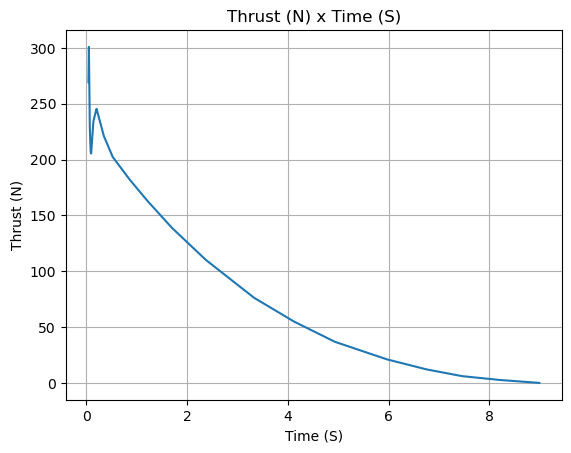

In [27]:
I100_17A = GenericMotor(
    thrust_source=r"C:\Users\EDUARDO\Documents\GRUPO DE COHETERIA ULE\SIMU\L1.2\escalado\Cesaroni pro54\Cesaroni_PRO54_2G_614I100-17A_thrust_curve.csv", 
    burn_time=(0.042, 8.993), # introducir el rango de tiempo de combustión sgún aparece en la primera columna del archivo csv
    chamber_radius=0.027, #radio del motor
    chamber_height=0.236, # longitud del motor sin contar tobera
    chamber_position=0.009, #longitud de la tobera
    propellant_initial_mass=0.350, 
    nozzle_radius=0.004, 
    dry_mass=0.457, # masa del motor despues del burn out (sin combustible)
    center_of_dry_mass_position=0.118, # posición de la mitad del motor aprox desde la salida de la tobera
    dry_inertia=(0.00222, 0.00222, 0.0002), # KG.M2 con peso en seco
    nozzle_position=0, 
    coordinate_system_orientation="nozzle_to_combustion_chamber"
)
I100_17A.info()

In [28]:
Leon_1_2 = Rocket(
    radius=0.04, # m
    mass=3, # kg, sin motor
    inertia=(0.08, 0.08, 0), # kg*m2
    power_off_drag=r"C:\Users\EDUARDO\Documents\GRUPO DE COHETERIA ULE\SIMU\L1.2\escalado\L1.2_escalado_dragcurve_poweroff(comas).csv",
    power_on_drag=r"C:\Users\EDUARDO\Documents\GRUPO DE COHETERIA ULE\SIMU\L1.2\escalado\L1.2_escalado_dragcurve_poweroff(comas).csv",
    center_of_mass_without_motor=0.633, # posición del cg en m desde la cola
    coordinate_system_orientation="tail_to_nose",
)


In [29]:
punta_1 = Leon_1_2.add_nose(
    length=0.366, 
    kind="tangent", 
    position=1.406 # longitud total del cohete
)
punta_1.info()

Geometric information of NoseCone:
----------------------------------
Length: 0.366 m
Kind: tangent
Base radius: 0.040 m
Reference rocket radius: 0.040 m
Reference radius ratio: 1.000

Lift information of the AeroSurface:
-----------------------------------
Center of Pressure position in local coordinates: (0.000, 0.000, 0.170)
Lift coefficient derivative at Mach 0 and AoA 0: 2.000 1/rad



In [30]:
# añadir aletas
aletas_1 = Leon_1_2.add_trapezoidal_fins(
    n=4,
    root_chord=0.16,
    tip_chord=0.08,
    span=0.08,
    position=0.16, # cuerda en la raíz + desplazamiento 
    sweep_angle = 26.57
)
aletas_1.info()

Geometric information of the fin set:
-------------------------------------
Number of fins: 4
Reference rocket radius: 0.040 m
Tip chord: 0.080 m
Root chord: 0.160 m
Span: 0.080 m
Cant angle: 0.000 ° or 0.000 rad
Longitudinal section area: 0.010 m²
Aspect ratio: 1.333 
Gamma_c: 0.000 m
Mean aerodynamic chord: 0.036 m

Lift information of the fin set:
--------------------------------
Lift interference factor: 1.333 m
Center of Pressure position in local coordinates: (0.000, 0.000, 0.049)
Lift Coefficient derivative (single fin) at Mach 0 and AoA 0: 3.633
Lift Coefficient derivative (fin set) at Mach 0 and AoA 0: 9.689


In [31]:
Leon_1_2.add_motor(I100_17A, position=-0.009) #la posición es la longitud de la tobera negativa

In [32]:
Leon_1_2.info()


Inertia Details

Rocket Mass: 3.000 kg (without motor)
Rocket Dry Mass: 3.457 kg (with unloaded motor)
Rocket Loaded Mass: 3.807 kg
Rocket Structural Mass Ratio: 0.908
Rocket Inertia (with unloaded motor) 11: 0.191 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.191 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.04 m
Rocket Frontal Area: 0.005027 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.069 m
Rocket Center of Dry Mass - Nozzle Exit: 0.573 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.564 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.052 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 9.689/rad

Center of Pressure

Nose Con

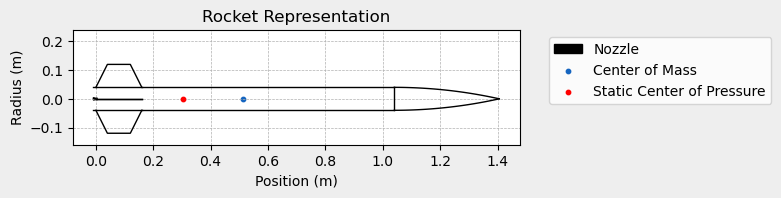

In [33]:
Leon_1_2.draw()

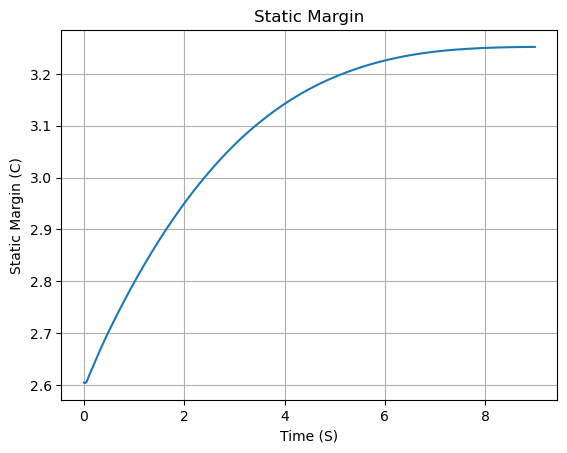

In [34]:
Leon_1_2.plots.static_margin()

Leon_1_v1.add_parachute(
    name="main",
    cd_s=0.226,           # cd x Sref=0.8xpixr^2 [m2]
    trigger='apogee'      # ejection altitude in meters
)

In [35]:
test_flight = Flight(
    rocket=Leon_1_2, 
    environment=env, 
    rail_length=3, 
    inclination=89, 
    heading=0
)


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 1.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 1.000 | e1: -0.009 | e2: 0.000 | e3: 0.000
Euler Angles - Spin φ : 0.00° | Nutation θ: -1.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.604 c

Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s

Launch Rail

Launch Rail Length: 3 m
Launch Rail Inclination: 89.00°
Launch Rail Heading: 0.00°

Rail Departure State

Rail Departure Time: 0.379 s
Rail Departure Velocity: 17.502 m/s
Rail Departure Stability Margin: 2.680 c
Rail Departure Angle of Attack: -0.000°
Rail Departure Thrust-Weight Ratio: 5.897
Rail Departure Reynolds Number: 9.582e+04

Burn out State

Burn out time: 8.993 s
Altitude at burn out: 674.406 m (ASL) | 673.406 m (AGL)
Rocket speed at burn out: 59.786 m/s
Freestream velocity at burn 

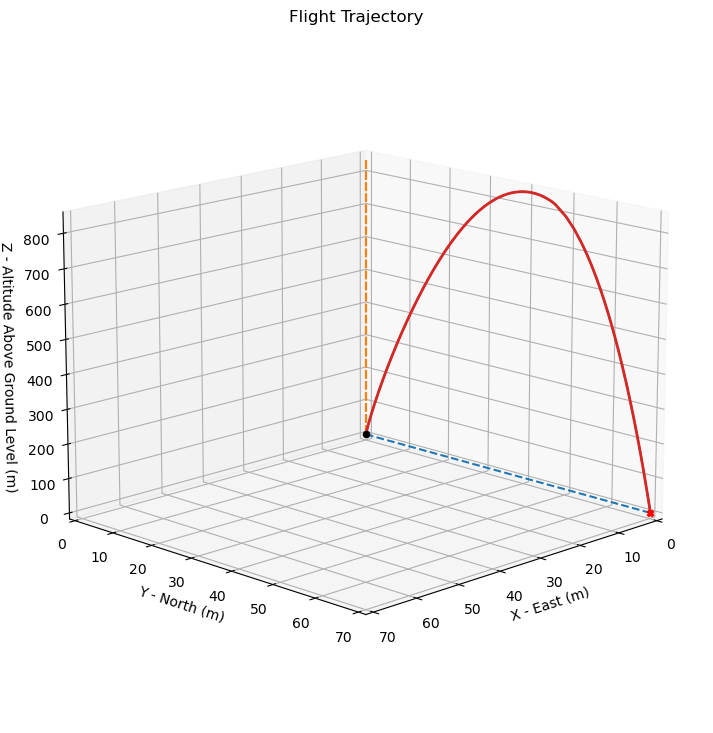

In [36]:
test_flight.prints.initial_conditions()
test_flight.prints.surface_wind_conditions()
test_flight.prints.launch_rail_conditions()
test_flight.prints.out_of_rail_conditions()
test_flight.prints.burn_out_conditions()
test_flight.prints.apogee_conditions()
test_flight.prints.impact_conditions()
test_flight.prints.maximum_values()
test_flight.plots.trajectory_3d()